Упражнение 1

In [5]:
import numpy as np
import matplotlib.pyplot as plt

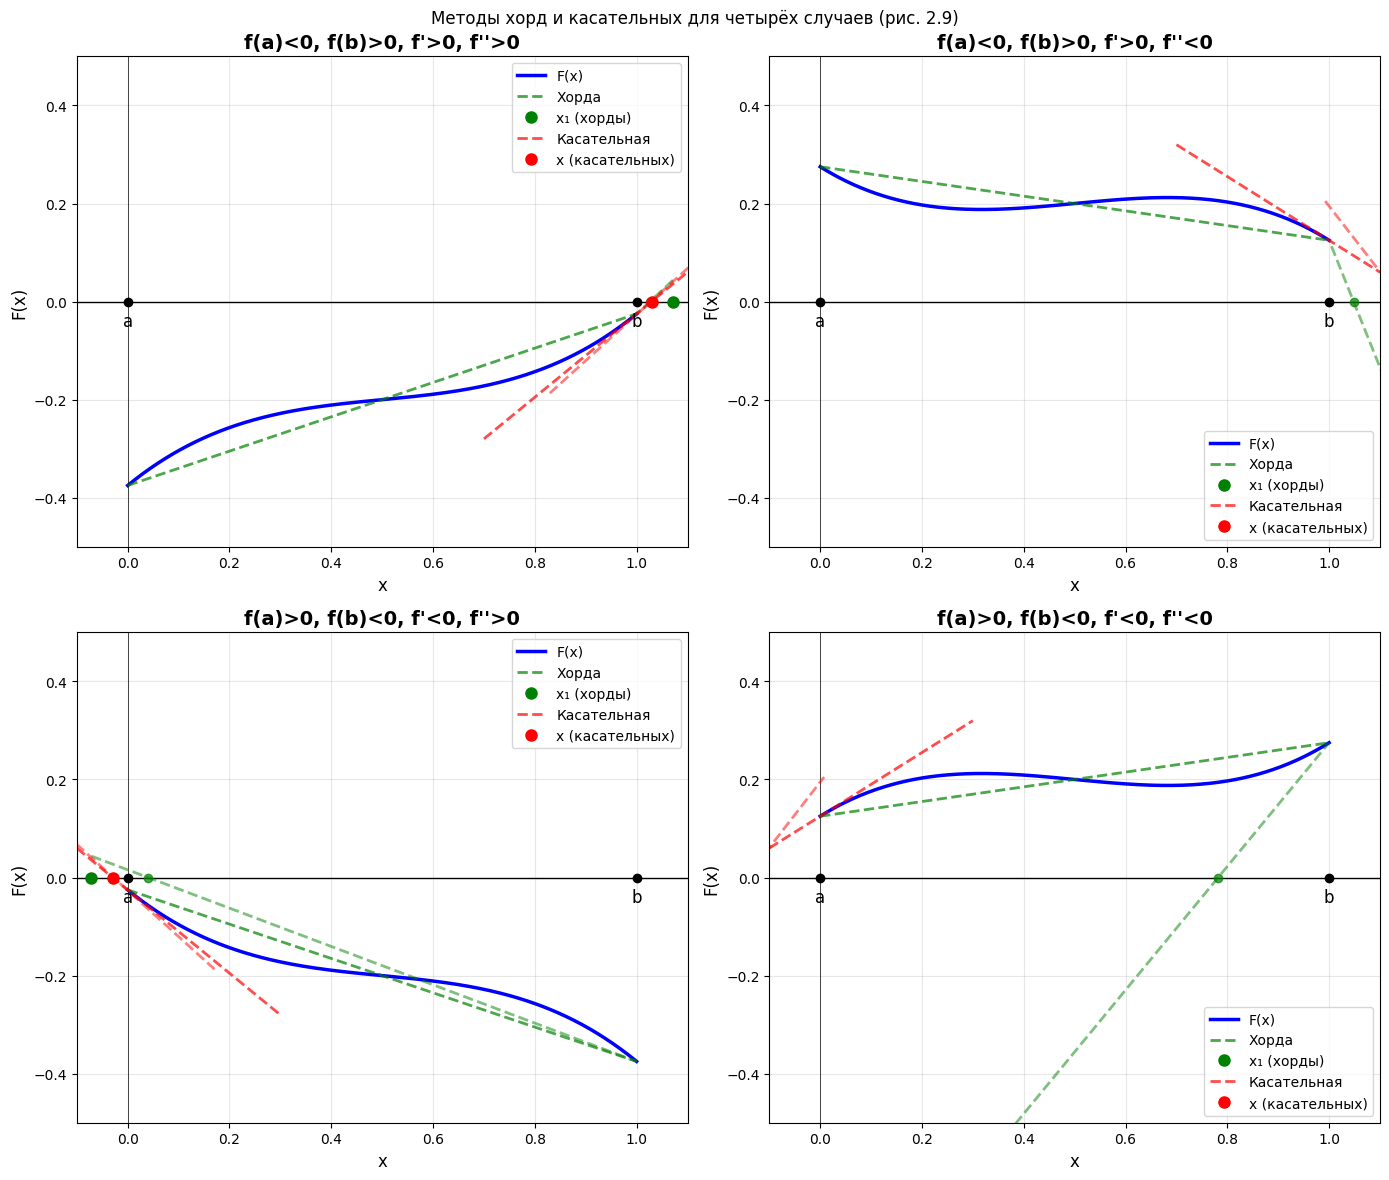

In [ ]:
def case1(x):
    return (x - 0.5)**3 + 0.1*(x - 0.5) - 0.2

def case2(x):
    return -((x - 0.5)**3) + 0.1*(x - 0.5) + 0.2

def case3(x):
    return -((x - 0.5)**3) - 0.1*(x - 0.5) - 0.2

def case4(x):
    return (x - 0.5)**3 - 0.1*(x - 0.5) + 0.2

cases = [case1, case2, case3, case4]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (func, title) in enumerate(zip(cases)):
    ax = axes[i]
    x_vals = np.linspace(0, 1, 400)
    y_vals = func(x_vals)
    
    ax.plot(x_vals, y_vals, 'b-', linewidth=2.5, label='F(x)')
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=0.5)
    
    a, b = 0, 1
    ax.plot([a, b], [0, 0], 'ko', markersize=6)
    ax.text(a, -0.05, 'a', fontsize=12, ha='center')
    ax.text(b, -0.05, 'b', fontsize=12, ha='center')
    
    root_idx = np.where(np.diff(np.sign(y_vals)))[0]
    if len(root_idx) > 0:
        root_x = x_vals[root_idx[0]]
        root_y = func(root_x)
        ax.plot(root_x, root_y, 'k*', markersize=12, label='Корень ξ')

    x_chord1 = a - func(a) * (b - a) / (func(b) - func(a))
    y_chord1 = 0
    ax.plot([a, b], [func(a), func(b)], 'g--', linewidth=2, alpha=0.7, label='Хорда')
    ax.plot(x_chord1, y_chord1, 'go', markersize=8, label='x₁ (хорды)')
    
    x_chord2 = x_chord1 - func(x_chord1) * (b - x_chord1) / (func(b) - func(x_chord1))
    ax.plot([x_chord1, b], [func(x_chord1), func(b)], 'g--', linewidth=2, alpha=0.5)
    ax.plot(x_chord2, 0, 'go', markersize=6, alpha=0.7)
    h = 1e-5
    
    if i < 2:
        df_b = (func(b + h) - func(b - h)) / (2*h)
        x_tang1 = b - func(b) / df_b
        
        x_tan_line = np.linspace(b-0.3, b+0.1, 10)
        y_tan_line = func(b) + df_b * (x_tan_line - b)
        ax.plot(x_tan_line, y_tan_line, 'r--', linewidth=2, alpha=0.7, label='Касательная')
        ax.plot(x_tang1, 0, 'ro', markersize=8, label='x (касательных)')
        
        df_tang = (func(x_tang1 + h) - func(x_tang1 - h)) / (2*h)
        x_tang2 = x_tang1 - func(x_tang1) / df_tang
        x_tan_line2 = np.linspace(x_tang1-0.2, x_tang1+0.1, 10)
        y_tan_line2 = func(x_tang1) + df_tang * (x_tan_line2 - x_tang1)
        ax.plot(x_tan_line2, y_tan_line2, 'r--', linewidth=2, alpha=0.5)
        ax.plot(x_tang2, 0, 'ro', markersize=6, alpha=0.7)
    
    else:
        df_a = (func(a + h) - func(a - h)) / (2*h)
        x_tang1 = a - func(a) / df_a
        
        x_tan_line = np.linspace(a-0.1, a+0.3, 10)
        y_tan_line = func(a) + df_a * (x_tan_line - a)
        ax.plot(x_tan_line, y_tan_line, 'r--', linewidth=2, alpha=0.7, label='Касательная')
        ax.plot(x_tang1, 0, 'ro', markersize=8, label='x (касательных)')
        
        df_tang = (func(x_tang1 + h) - func(x_tang1 - h)) / (2*h)
        x_tang2 = x_tang1 - func(x_tang1) / df_tang
        x_tan_line2 = np.linspace(x_tang1-0.2, x_tang1+0.2, 10)
        y_tan_line2 = func(x_tang1) + df_tang * (x_tan_line2 - x_tang1)
        ax.plot(x_tan_line2, y_tan_line2, 'r--', linewidth=2, alpha=0.5)
        ax.plot(x_tang2, 0, 'ro', markersize=6, alpha=0.7)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('F(x)', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.5, 0.5)

plt.suptitle('Методы хорд и касательных для четырёх случаев (рис. 2.9)')
plt.tight_layout()
plt.show()

Упражнение 2

In [13]:
iteration = 0
def f(x):
    return x**3 + 3*x**2 - 24*x + 1

def df(x):
    return 3*x**2 + 6*x - 24

def mandarin(a, b, eps):
    while True:
        fa, fb = f(a), f(b)
        dfa, dfb = df(a), df(b)
        
        x = a - fa * (b - a) / (fb - fa)
        y = b - fb / dfb
        
        if abs(f(x)) < eps and abs(f(y)) < eps:
            return (x + y) / 2
        
        if f(x) * f(y) < 0:
            a, b = min(x, y), max(x, y)
        else:
            if abs(x - b) < abs(y - a):
                b = x
            else:
                a = y

root = mandarin(0, 1, 0.000001)
print(f"{root:.6f}")
print(f"Номер итерации: {iteration}")

0.041889
Номер итерации: 0


In [20]:
def f(x):
    return x**3 + 3*x**2 - 24*x + 1

def df(x):
    return 3*x**2 + 6*x - 24

def combined_method(a, b, eps):
    iteration = 1
    while True:
        fa, fb = f(a), f(b)
        dfa, dfb = df(a), df(b)
        
        x = a - fa * (b - a) / (fb - fa)
        y = b - fb / dfb
        
        print(f"Итерация {iteration}: x = {x:.6f}, y = {y:.6f}, f(x) = {f(x):.6f}, f(y) = {f(y):.6f}")
        
        if abs(f(x)) < eps and abs(f(y)) < eps:
            root = (x + y) / 2
            print(f"Корень найден на итерации {iteration}: {root:.6f}")
            return root
        
        if f(x) * f(y) < 0:
            a, b = min(x, y), max(x, y)
        else:
            if abs(x - b) < abs(y - a):
                b = x
            else:
                a = y
        
        iteration += 1

root = combined_method(0, 1, 0.000001)

Итерация 1: x = 0.050000, y = -0.266667, f(x) = -0.192375, f(y) = 7.594370
Итерация 2: x = 0.042177, y = 0.041880, f(x) = -0.006827, f(y) = 0.000207
Итерация 3: x = 0.041889, y = 0.041889, f(x) = -0.000000, f(y) = 0.000000
Корень найден на итерации 3: 0.041889
